# Rep. 4. Checkpoint 2. Estrategias I 

Dayanni Godoy Rosales

### Estrategias Direccionales de Trading con Opciones

Las cuatro estrategias son:
1. **Long Straddle** – Apuesta a que SPY se mueve mucho (en cualquier dirección)
2. **Long Strangle** – Igual que el straddle pero más barato, necesita mayor movimiento
3. **Bull Call Spread** – Visión alcista moderada
4. **Bear Put Spread** – Visión bajista moderada

In [1]:
!pip install yfinance --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

Usamos `yfinance` para descargar:
- El **precio spot** actual de SPY
- Los **precios mid** (punto medio entre bid y ask) de opciones con vencimiento 17-abr-2026

In [2]:
spy    = yf.Ticker('SPY')
S0     = spy.history(period='1d')['Close'].iloc[-1]
print(f"Precio actual de SPY  : ${S0:.2f}")

EXPIRY = '2026-04-17'
chain  = spy.option_chain(EXPIRY)

calls = chain.calls.copy()
puts  = chain.puts.copy()

calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid']  = (puts['bid']  + puts['ask'])  / 2

calls_clean = calls[['strike','bid','ask','mid','impliedVolatility']].reset_index(drop=True)
puts_clean  = puts[['strike','bid','ask','mid','impliedVolatility']].reset_index(drop=True)

print(f"\nVencimiento analizado : {EXPIRY}")
print(f"Strikes disponibles   : {len(calls_clean)} calls / {len(puts_clean)} puts")
print("\n--- Calls (muestra alrededor de S0) ---")
mask_c = (calls_clean['strike'] >= S0 - 30) & (calls_clean['strike'] <= S0 + 50)
print(calls_clean[mask_c].to_string(index=False))
print("\n--- Puts (muestra alrededor de S0) ---")
mask_p = (puts_clean['strike'] >= S0 - 50) & (puts_clean['strike'] <= S0 + 30)
print(puts_clean[mask_p].to_string(index=False))

Precio actual de SPY  : $679.86

Vencimiento analizado : 2026-04-17
Strikes disponibles   : 249 calls / 224 puts

--- Calls (muestra alrededor de S0) ---
 strike   bid   ask    mid  impliedVolatility
  650.0 31.83 31.92 31.875           0.268501
  651.0 30.79 31.01 30.900           0.265938
  652.0 29.63 29.85 29.740           0.252998
  653.0 28.64 29.29 28.965           0.264168
  654.0 27.90 28.38 28.140           0.260994
  655.0 26.89 26.98 26.935           0.239143
  656.0 26.15 26.25 26.200           0.242805
  657.0 25.21 25.40 25.305           0.241585
  658.0 24.29 24.48 24.385           0.237617
  659.0 23.36 23.57 23.465           0.233833
  660.0 22.51 22.62 22.565           0.228523
  661.0 21.58 21.78 21.680           0.226753
  662.0 20.64 20.82 20.730           0.220833
  663.0 19.76 20.00 19.880           0.219185
  664.0 18.89 19.10 18.995           0.214791
  665.0 18.07 18.17 18.120           0.209358
  666.0 17.23 17.33 17.280           0.206368
  667.0 16.33 16.5

- `payoff_estrategia`: calcula la ganancia/pérdida para cada precio posible de SPY al vencimiento
- `graficar_estrategia`: dibuja el payoff diagram

In [10]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el PnL total de una estrategia multi-pierna al vencimiento.
    Parametros:
        S_range : array de precios posibles de SPY al vencimiento
        legs    : lista de patas, cada una con:
                    'tipo'     -> 'call' o 'put'
                    'K'        -> strike
                    'prima'    -> prima pagada o cobrada
                    'posicion' -> +1 si compramos, -1 si vendemos
    """
    pnl = np.zeros_like(S_range, dtype=float)
    for leg in legs:
        K, prima, pos = leg['K'], leg['prima'], leg['posicion']
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - K, 0)
        else:
            payoff = np.maximum(K - S_range, 0)
        # Comprador: gana el payoff pero paga la prima
        # Vendedor:  cobra la prima pero asume el payoff negativo
        pnl += pos * (payoff - prima)
    return pnl


def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Dibuja el payoff diagram de una estrategia."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(S_range, pnl, 0, where=(pnl >= 0),
                    alpha=0.25, color='green', label='Zona de ganancia')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0),
                    alpha=0.25, color='red',   label='Zona de perdida')
    ax.plot(S_range, pnl, color='steelblue', linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        colores_k = ['gray', 'purple', 'brown', 'orange']
        for i, (k_val, k_lbl) in enumerate(K_lines):
            ax.axvline(k_val, color=colores_k[i % len(colores_k)],
                       linewidth=1, linestyle=':', label=k_lbl)
    if S0 is not None:
        ax.axvline(S0, color='limegreen', linewidth=1.5,
                   linestyle='--', label=f'S0 = ${S0:.2f}')
    ax.set_xlabel('Precio de SPY al vencimiento ($)', fontsize=11)
    ax.set_ylabel('Ganancia / Perdida ($)', fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    plt.tight_layout()
    plt.show()

Buscamos en la cadena de opciones los strikes más adecuados para cada estrategia:
- **ATM**: más cercano al precio actual de SPY (para straddle y base de los spreads)
- **OTM ± 30 pts**: alejados del precio actual (para strangle y los extremos de los spreads)

In [4]:
def get_mid(df, strike):
    """Devuelve el strike real y el precio mid mas cercano al strike pedido."""
    idx = (df['strike'] - strike).abs().idxmin()
    row = df.loc[idx]
    return float(row['strike']), float(row['mid'])

# Strikes base
K_atm      = round(S0 / 5) * 5    # redondeamos al multiplo de 5 mas cercano

K_call_otm = K_atm + 30
K_put_otm  = K_atm - 30

K1_bull, K2_bull = K_atm,      K_atm + 30
K1_bear, K2_bear = K_atm,      K_atm - 30

# Precios mid reales desde la cadena de opciones
K_atm,       C_atm    = get_mid(calls_clean, K_atm)
_,            P_atm    = get_mid(puts_clean,  K_atm)
K_call_otm,   C_otm    = get_mid(calls_clean, K_call_otm)
K_put_otm,    P_otm    = get_mid(puts_clean,  K_put_otm)
K1_bull,      C1_bull  = get_mid(calls_clean, K1_bull)
K2_bull,      C2_bull  = get_mid(calls_clean, K2_bull)
K1_bear,      P1_bear  = get_mid(puts_clean,  K1_bear)
K2_bear,      P2_bear  = get_mid(puts_clean,  K2_bear)

print(f"{'='*55}")
print(f"  Precio actual de SPY (S0)  : ${S0:.2f}")
print(f"  Vencimiento                : {EXPIRY}")
print(f"{'='*55}")
print(f"\n  LONG STRADDLE")
print(f"    Strike ATM (K)  : {K_atm}  |  Call mid ${C_atm:.2f}  |  Put mid ${P_atm:.2f}")
print(f"\n  LONG STRANGLE")
print(f"    K call OTM      : {K_call_otm}  ->  mid ${C_otm:.2f}")
print(f"    K put  OTM      : {K_put_otm}  ->  mid ${P_otm:.2f}")
print(f"\n  BULL CALL SPREAD")
print(f"    K1 (compra call): {K1_bull}  ->  mid ${C1_bull:.2f}")
print(f"    K2 (vende call) : {K2_bull}  ->  mid ${C2_bull:.2f}")
print(f"\n  BEAR PUT SPREAD")
print(f"    K1 (compra put) : {K1_bear}  ->  mid ${P1_bear:.2f}")
print(f"    K2 (vende put)  : {K2_bear}  ->  mid ${P2_bear:.2f}")

S_range = np.linspace(S0 - 120, S0 + 120, 600)

  Precio actual de SPY (S0)  : $679.86
  Vencimiento                : 2026-04-17

  LONG STRADDLE
    Strike ATM (K)  : 680.0  |  Call mid $6.61  |  Put mid $5.47

  LONG STRANGLE
    K call OTM      : 710.0  ->  mid $0.04
    K put  OTM      : 650.0  ->  mid $0.69

  BULL CALL SPREAD
    K1 (compra call): 680.0  ->  mid $6.61
    K2 (vende call) : 710.0  ->  mid $0.04

  BEAR PUT SPREAD
    K1 (compra put) : 680.0  ->  mid $5.47
    K2 (vende put)  : 650.0  ->  mid $0.69


---
## Estrategia 1 — Long Straddle

**Compramos un call Y un put con el mismo strike (ATM) y el mismo vencimiento.**

- Gana cuando SPY se mueve **mucho** en cualquier direccion
- Pierde cuando SPY se queda **quieto** cerca del strike
- Perdida maxima = lo que pagamos por las dos opciones (si SPY termina exactamente en K)
- Ganancia = ilimitada en ambas direcciones
- Break-evens: K + costo total (arriba) y K - costo total (abajo)

Long Straddle  (K = 680.0)
  Costo total (prima pagada) : $12.08
  Break-even superior        : $692.09
  Break-even inferior        : $667.91
  Perdida maxima             : -$12.08  (si SPY termina en $680.0)
  Ganancia maxima            : Ilimitada


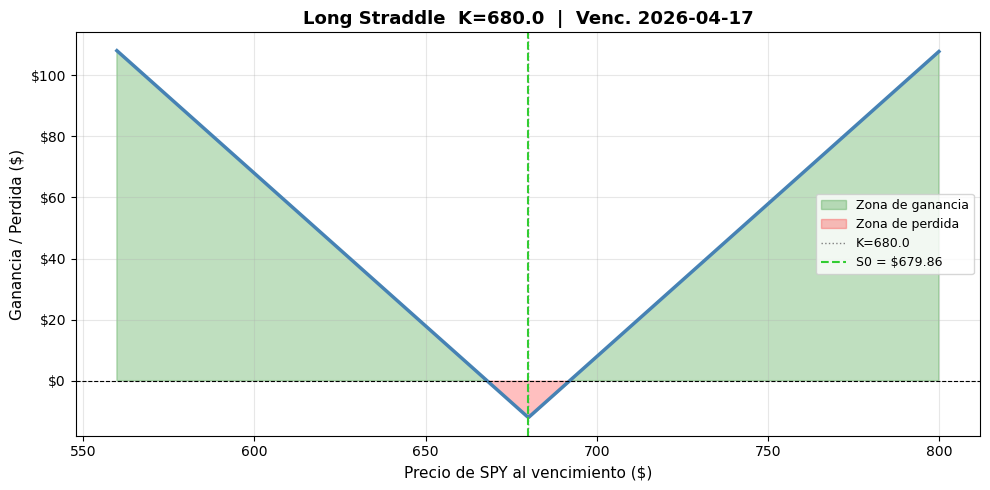

In [5]:
legs_straddle = [
    {'tipo': 'call', 'K': K_atm, 'prima': C_atm, 'posicion': +1},
    {'tipo': 'put',  'K': K_atm, 'prima': P_atm, 'posicion': +1},
]
pnl_straddle   = payoff_estrategia(S_range, legs_straddle)

costo_straddle = C_atm + P_atm
be_sup_str     = K_atm + costo_straddle
be_inf_str     = K_atm - costo_straddle

print(f"Long Straddle  (K = {K_atm})")
print(f"  Costo total (prima pagada) : ${costo_straddle:.2f}")
print(f"  Break-even superior        : ${be_sup_str:.2f}")
print(f"  Break-even inferior        : ${be_inf_str:.2f}")
print(f"  Perdida maxima             : -${costo_straddle:.2f}  (si SPY termina en ${K_atm})")
print(f"  Ganancia maxima            : Ilimitada")

graficar_estrategia(
    S_range, pnl_straddle,
    f'Long Straddle  K={K_atm}  |  Venc. {EXPIRY}',
    S0=S0, K_lines=[(K_atm, f'K={K_atm}')]
)

---
## Estrategia 2 — Long Strangle

**Igual que el straddle, pero los strikes estan separados:** call OTM arriba y put OTM abajo.

- Mas barato que el straddle (opciones fuera del dinero cuestan menos)
- Necesita un movimiento mayor de SPY para ser rentable
- Perdida maxima = prima del call OTM + prima del put OTM (si SPY queda entre los dos strikes)
- Break-evens estan mas alejados del precio actual

Long Strangle  (K_put=650.0  |  K_call=710.0)
  Costo total                : $0.73  (vs $12.08 del straddle)
  Ahorro vs straddle         : $11.35
  Break-even superior        : $710.73
  Break-even inferior        : $649.27
  Perdida maxima             : -$0.73  (si SPY queda entre 650.0 y 710.0)
  Ganancia maxima            : Ilimitada

  El strangle necesita que SPY se mueva ~$18.64 mas al alza
  y ~$18.64 mas a la baja vs el straddle para ser rentable.


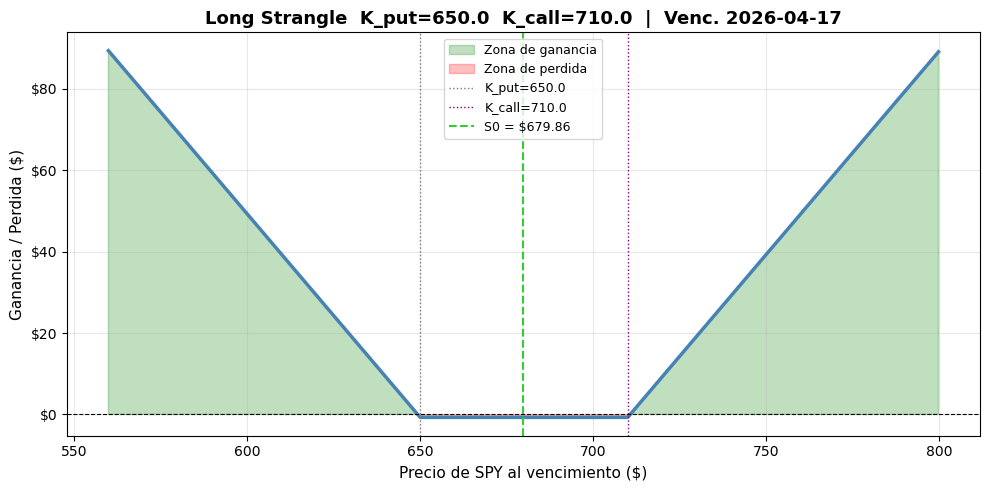

In [6]:
legs_strangle = [
    {'tipo': 'call', 'K': K_call_otm, 'prima': C_otm, 'posicion': +1},
    {'tipo': 'put',  'K': K_put_otm,  'prima': P_otm,  'posicion': +1},
]
pnl_strangle   = payoff_estrategia(S_range, legs_strangle)

costo_strangle = C_otm + P_otm
be_sup_sng     = K_call_otm + costo_strangle
be_inf_sng     = K_put_otm  - costo_strangle
ahorro         = costo_straddle - costo_strangle
extra_mov_sup  = be_sup_sng - be_sup_str
extra_mov_inf  = be_inf_str - be_inf_sng

print(f"Long Strangle  (K_put={K_put_otm}  |  K_call={K_call_otm})")
print(f"  Costo total                : ${costo_strangle:.2f}  (vs ${costo_straddle:.2f} del straddle)")
print(f"  Ahorro vs straddle         : ${ahorro:.2f}")
print(f"  Break-even superior        : ${be_sup_sng:.2f}")
print(f"  Break-even inferior        : ${be_inf_sng:.2f}")
print(f"  Perdida maxima             : -${costo_strangle:.2f}  (si SPY queda entre {K_put_otm} y {K_call_otm})")
print(f"  Ganancia maxima            : Ilimitada")
print(f"")
print(f"  El strangle necesita que SPY se mueva ~${extra_mov_sup:.2f} mas al alza")
print(f"  y ~${extra_mov_inf:.2f} mas a la baja vs el straddle para ser rentable.")

graficar_estrategia(
    S_range, pnl_strangle,
    f'Long Strangle  K_put={K_put_otm}  K_call={K_call_otm}  |  Venc. {EXPIRY}',
    S0=S0,
    K_lines=[(K_put_otm, f'K_put={K_put_otm}'), (K_call_otm, f'K_call={K_call_otm}')]
)

---
## Estrategia 3 — Bull Call Spread

**Compramos call K1 y vendemos call K2 (K1 < K2), ambos calls.**

- Gana cuando SPY **sube** por encima de K1
- La venta del call K2 reduce el costo pero limita la ganancia maxima en K2
- Perdida maxima = prima neta pagada (si SPY termina debajo de K1)
- Ganancia maxima = (K2 - K1) - prima neta (si SPY termina encima de K2)

Bull Call Spread  (K1=680.0  |  K2=710.0)
  Prima neta pagada  : $6.56
  Ganancia maxima    : $23.44   (si SPY >= 710.0)
  Perdida maxima     : -$6.56  (si SPY <= 680.0)
  Break-even         : $686.57


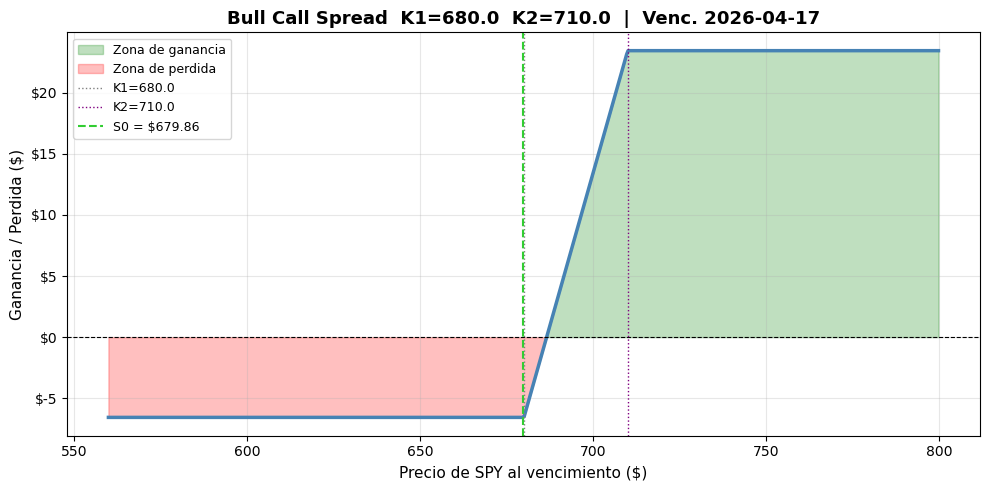

In [7]:
legs_bull = [
    {'tipo': 'call', 'K': K1_bull, 'prima': C1_bull, 'posicion': +1},
    {'tipo': 'call', 'K': K2_bull, 'prima': C2_bull, 'posicion': -1},
]
pnl_bull        = payoff_estrategia(S_range, legs_bull)

prima_neta_bull = C1_bull - C2_bull
gan_max_bull    = (K2_bull - K1_bull) - prima_neta_bull
be_bull         = K1_bull + prima_neta_bull

print(f"Bull Call Spread  (K1={K1_bull}  |  K2={K2_bull})")
print(f"  Prima neta pagada  : ${prima_neta_bull:.2f}")
print(f"  Ganancia maxima    : ${gan_max_bull:.2f}   (si SPY >= {K2_bull})")
print(f"  Perdida maxima     : -${prima_neta_bull:.2f}  (si SPY <= {K1_bull})")
print(f"  Break-even         : ${be_bull:.2f}")

graficar_estrategia(
    S_range, pnl_bull,
    f'Bull Call Spread  K1={K1_bull}  K2={K2_bull}  |  Venc. {EXPIRY}',
    S0=S0,
    K_lines=[(K1_bull, f'K1={K1_bull}'), (K2_bull, f'K2={K2_bull}')]
)

---
## Estrategia 4 — Bear Put Spread

**Compramos put K1 y vendemos put K2 (K2 < K1), ambos puts.**

- Gana cuando SPY **baja** por debajo de K1
- La venta del put K2 reduce el costo pero limita la ganancia maxima en K2
- Perdida maxima = prima neta pagada (si SPY termina encima de K1)
- Ganancia maxima = (K1 - K2) - prima neta (si SPY termina debajo de K2)

Bear Put Spread  (K1=680.0  |  K2=650.0)
  Prima neta pagada  : $4.79
  Ganancia maxima    : $25.21   (si SPY <= 650.0)
  Perdida maxima     : -$4.79  (si SPY >= 680.0)
  Break-even         : $675.21


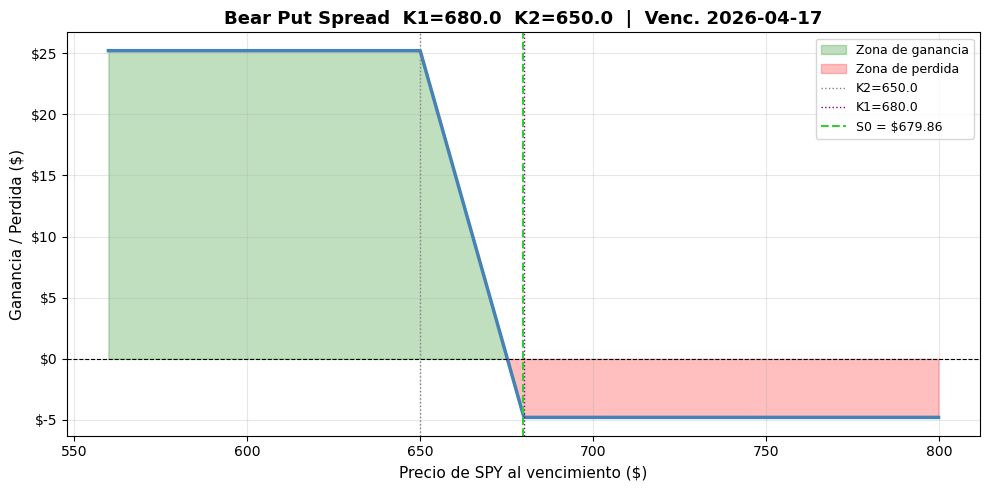

In [8]:
legs_bear = [
    {'tipo': 'put', 'K': K1_bear, 'prima': P1_bear, 'posicion': +1},
    {'tipo': 'put', 'K': K2_bear, 'prima': P2_bear, 'posicion': -1},
]
pnl_bear        = payoff_estrategia(S_range, legs_bear)

prima_neta_bear = P1_bear - P2_bear
gan_max_bear    = (K1_bear - K2_bear) - prima_neta_bear
be_bear         = K1_bear - prima_neta_bear

print(f"Bear Put Spread  (K1={K1_bear}  |  K2={K2_bear})")
print(f"  Prima neta pagada  : ${prima_neta_bear:.2f}")
print(f"  Ganancia maxima    : ${gan_max_bear:.2f}   (si SPY <= {K2_bear})")
print(f"  Perdida maxima     : -${prima_neta_bear:.2f}  (si SPY >= {K1_bear})")
print(f"  Break-even         : ${be_bear:.2f}")

graficar_estrategia(
    S_range, pnl_bear,
    f'Bear Put Spread  K1={K1_bear}  K2={K2_bear}  |  Venc. {EXPIRY}',
    S0=S0,
    K_lines=[(K2_bear, f'K2={K2_bear}'), (K1_bear, f'K1={K1_bear}')]
)

---
## Tabla Resumen de las Cuatro Estrategias

In [9]:
resumen = pd.DataFrame([
    {
        'Estrategia'           : 'Long Straddle',
        'Costo / Prima neta'   : f'${costo_straddle:.2f}',
        'Perdida maxima'       : f'-${costo_straddle:.2f}',
        'Ganancia maxima'      : 'Ilimitada',
        'Break-even(s)'        : f'${be_inf_str:.2f}  |  ${be_sup_str:.2f}',
    },
    {
        'Estrategia'           : 'Long Strangle',
        'Costo / Prima neta'   : f'${costo_strangle:.2f}',
        'Perdida maxima'       : f'-${costo_strangle:.2f}',
        'Ganancia maxima'      : 'Ilimitada',
        'Break-even(s)'        : f'${be_inf_sng:.2f}  |  ${be_sup_sng:.2f}',
    },
    {
        'Estrategia'           : 'Bull Call Spread',
        'Costo / Prima neta'   : f'${prima_neta_bull:.2f}',
        'Perdida maxima'       : f'-${prima_neta_bull:.2f}',
        'Ganancia maxima'      : f'${gan_max_bull:.2f}',
        'Break-even(s)'        : f'${be_bull:.2f}',
    },
    {
        'Estrategia'           : 'Bear Put Spread',
        'Costo / Prima neta'   : f'${prima_neta_bear:.2f}',
        'Perdida maxima'       : f'-${prima_neta_bear:.2f}',
        'Ganancia maxima'      : f'${gan_max_bear:.2f}',
        'Break-even(s)'        : f'${be_bear:.2f}',
    },
])

pd.set_option('display.max_colwidth', 30)
print(f"Tabla resumen — SPY vencimiento {EXPIRY}  |  S0 = ${S0:.2f}")
print()
print(resumen.to_string(index=False))

Tabla resumen — SPY vencimiento 2026-04-17  |  S0 = $679.86

      Estrategia Costo / Prima neta Perdida maxima Ganancia maxima       Break-even(s)
   Long Straddle             $12.08        -$12.08       Ilimitada $667.91  |  $692.09
   Long Strangle              $0.73         -$0.73       Ilimitada $649.27  |  $710.73
Bull Call Spread              $6.56         -$6.56          $23.44             $686.57
 Bear Put Spread              $4.79         -$4.79          $25.21             $675.21


# Preguntas 

## Pregunta 1
**Con el S0 actual, ¿cual de las cuatro estrategias esta mas cerca de su zona de maxima perdida?  
¿Que te dice eso sobre la vision de mercado que expresa?**

Con S0 corriendo cerca del strike ATM, el Long Straddle es la estrategia mas cerca de su zona de maxima perdida: esta ocurre exactamente cuando SPY termina en K, y hoy S0 ≈ K.

Los spreads (bull y bear) solo pierden lo maximo si SPY cae o sube mucho, respectivamente; el strangle pierde lo maximo si SPY se queda entre sus dos strikes.

## Pregunta 2
**Compara el costo total del long straddle vs. el long strangle.  
¿Cuanto mas barato es el strangle? ¿Cuanto mas tiene que moverse SPY para que el strangle sea rentable comparado con el straddle?**

El strangle usa opciones OTM (fuera del dinero), que son mas baratas porque tienen menor probabilidad de terminar con valor. Eso reduce el costo total vs el straddle.

Sin embargo, ese ahorro tiene un precio: los break-even points del strangle estan mas alejados del precio actual. SPY necesita un movimiento mas grande (aproximado por extra_mov_sup al alza y extra_mov_inf a la baja, calculados en la celda del strangle) para que la estrategia sea rentable.



## Pregunta 3
**Un long straddle gana si el mercado se mueve mucho. ¿Que pasa si compras el straddle justo despues de que la IV ya subio por anticipacion de un evento? ¿Sigue siendo una buena estrategia?**

**No necesariamente. Esta es una de las trampas mas clasicas al operar con opciones.**

El flujo es el siguiente:

1. Antes del evento (earnings, Fed, dato macro), todos anticipan movimiento → la IV sube → las opciones se encarecen.
2. Tu compras el straddle con IV alta → **pagas una prima inflada**.
3. El evento ocurre → aunque SPY se mueva, la IV **colapsa** inmediatamente (fenomeno conocido como *volatility crush*).
4. Tus opciones pierden el componente de volatilidad, incluso si la direccion fue la correcta.

**Ejemplo**: compras el straddle a $30 con IV al 40%. El dia del evento SPY se mueve $15. Pero la IV cae al 20% y el straddle ahora vale $20. **Perdiste $10 aunque el mercado se movio.**

El momento ideal para comprar un straddle es *antes* de que suba la IV (anticipar el anticipamiento), no cuando ya esta elevada.


## Pregunta 4
**El bull call spread limita la ganancia maxima comparado con un call simple. ¿Por que alguien aceptaria ese limite voluntariamente? Da al menos dos razones.**

**Razon 1 — Costo menor**  
Al vender el call K2, cobras una prima que reduce lo que pagas. Un call ATM puede costar $15; el bull spread puede costar $9. Eso significa que la perdida maxima es menor y el break-even esta mas cerca del precio actual. Necesitas menos movimiento de SPY para empezar a ganar.

**Razon 2 — Menor sensibilidad a caidas de volatilidad (vega reducida)**  
Un call simple tiene vega alta: si la IV baja, pierdes valor aunque SPY no se mueva. En el bull spread, el call comprado y el call vendido tienen vegas que se cancelan parcialmente. La posicion es mucho menos sensible a cambios de IV. Esto es valioso cuando la IV esta alta y podria colapsar.


## Pregunta 5
**Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento, ¿tiene sentido cerrar o esperar? ¿Que factores considerarias?**

**La respuesta depende del contexto, pero aqui estan los factores clave:**

**Razones para CERRAR antes del vencimiento:**
- El spread ya tiene un valor cercano a su maximo posible (K2 - K1 - prima). Puedes capturar esa ganancia ahora.
- Al cerrar evitas el **riesgo de reversion**: SPY podria bajar de vuelta por debajo de K2 antes del vencimiento y reducir tu ganancia.
- El tiempo que falta ya no genera valor adicional para ti; el riesgo de mantenerlo abierto no esta compensado.

**Razones para ESPERAR:**
- Si falta muy poco tiempo y SPY esta solidamente arriba de K2, las comisiones de cerrar pueden comerse parte de la ganancia.
- Si tienes otra razon para mantener la posicion (hedging de otra posicion, por ejemplo).

**Regla practica**: si el spread ya vale mas del 80% de su ganancia maxima teorica, generalmente conviene cerrar y reasignar el capital.

---
## Pregunta 6
**¿Como afecta un aumento de IV a un bull spread comparado con un long straddle?  
¿Cual de las dos posiciones es mas sensible a cambios en volatilidad implícita y por que?**

**El long straddle es mucho mas sensible a la IV (tiene mayor vega).**

| Estructura      | Posicion en vega      | Efecto de subida de IV |
|-----------------|----------------------|------------------------|
| Long Straddle   | Vega muy positiva (dos opciones compradas) | Gana mucho valor |
| Bull Call Spread| Vega cercana a cero (call comprado y call vendido se cancelan) | Efecto pequeno |

**¿Por que?**
- En el straddle compramos call + put, ambos con vega positiva. La vega total es la suma de las dos.
- En el bull spread compramos un call (vega +) y vendemos otro (vega -). Las exposiciones se cancelan parcialmente, dejando una vega neta muy baja.


## Pregunta 7
**En terminos de griegas, ¿cual es la diferencia principal entre comprar un call simple y comprar un bull call spread? ¿Que griega cambia mas drasticamente entre las dos estructuras?**

Vega es la que cambia más. Un call simple esta muy expuesto a cambios de volatilidad: si la IV sube, gana; si baja, pierde. El bull spread casi elimina esa exposicion porque la vega del call comprado (K1) y la del call vendido (K2) son similares y se restan mutuamente.